<a href="https://colab.research.google.com/github/bw123111/csci547_ML/blob/main/assignments/kaggle_competition1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kaggle competition #1
## Classifying edible VS not edible mushrooms

BELLA WENGAPPULY  
NetID: bw165311  
Worked with Christian Dupree

## Background
Mushrooms belong to the Fungi kingdom of organisms. Mushrooms are the reproductive fruiting body of fungi and often appear after rain or fire. Mushrooms don't usually last long, as they are meant to grow quickly and release spores that disperse via wind to germinate in a new location. "Mushrooms" spend the longest part of their lifecycle as mycelium, a fine net of fungal cells spread throughout the soil or decaying plant matter. If you have ever dug up some forest soil and found white strings, those are likely fungi! When conditions are suitable, this white, stringy mycelium will sprout mushrooms to reproduce. Mycelium fungi take nutrients from other organic materials, performing an essential ecosystem role as decomposers.  

### 3 Types of Mushrooms/Fungi

The [Missouri Department of Conservation](https://mdc.mo.gov/trees-plants/tree-and-plant-facts/mushroom-facts) describes the 3 types of fungi well:  
1) Some fungi digest nutrients from dead material, such as leaves and fallen trees — a compost heap hosts plenty of these fungi! The members of this group are called saprophytes.

2) Other fungi digest materials from living tissues — these are called parasites. When you see mushrooms growing from a living tree, that tree is undoubtedly being parasitized by a fungus under its bark.

3) The mycorrhizal fungi are a third group. Underground, they form a mutually beneficial relationship with the roots of plants. They help the plants to absorb water and minerals, and the plants provide nutrients for the fungus. Many trees, orchids, and other plants cannot live without these fungal partners.

### Edible or Not Edible, how to tell?
Mushrooms range widely in adverse side effects, and can be deadly. Other mushrooms are perfectly good eatin'! I'm sure you've had some of those good ones before, whether from the store or from foraging. Morels are a common forageable mushroom in Montana that many locals avidly hunt for in the spring. However, identifying the immense diversity of mushrooms can be incredibly difficult, and the stakes are life and death. Morels may seem distinctive, yet there are several "false morels" out there.

### True Morels
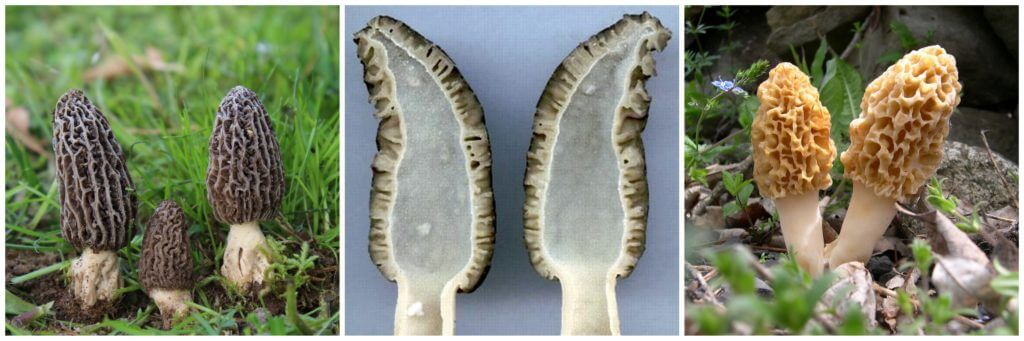

### False Morels
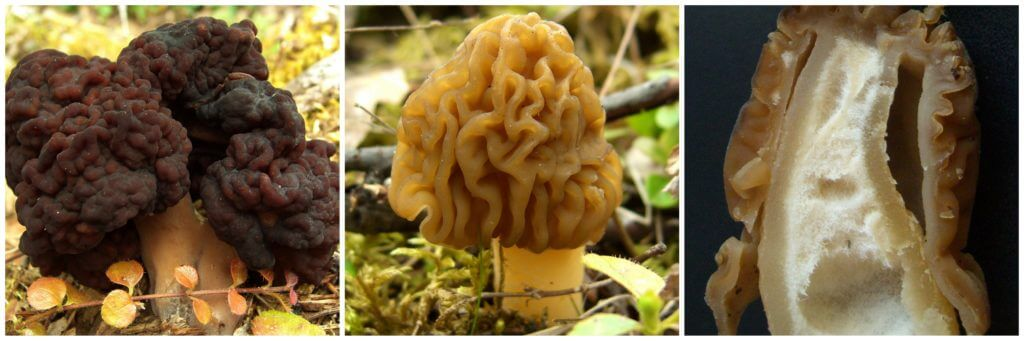

Foraging wild mushrooms can be incredibly dangerous because of similar species that may or may not be edible or deadly. If you'd like to learn more about foraging morels, visit [The Montana Natural History Center](https://www.montananaturalist.org/blog-post/hunting-morels-in-montana/) for more information. This [peer-reviewed publication](https://pubmed.ncbi.nlm.nih.gov/33599116/) reviewing the world's edible mushroom species may also serve as a good starting point. Always double check mushrooms with a field guide and spore print!  

## Anatomy and life cycle of a mushroom
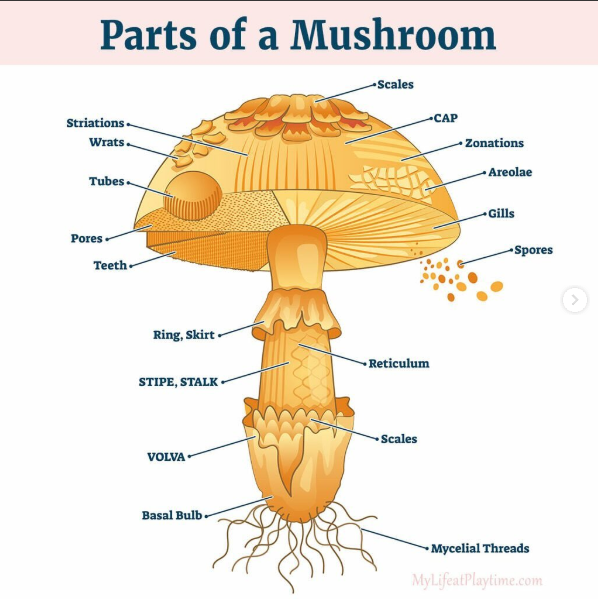

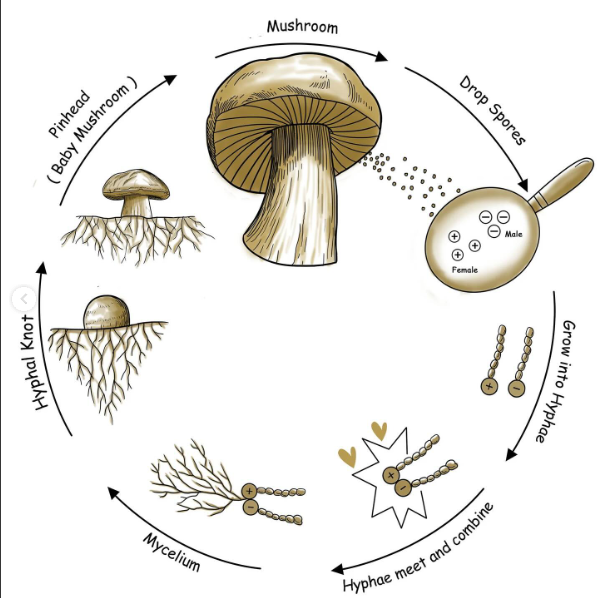

# Project Description
In this project, a Kaggle dataset of mushroom characteristics (e.g. cap shape, surface texture, color, odor, gill features, and habitat) will be used to predict whether a mushroom is edible or not. In the dataset, each row is an individual mushroom species described by the columns of categorical data. This categorical data includes edibility. The categorical data will be used to train a machine learning model for binary classification (edible/not edible).

## Approach
I have worked with scikit learn in a couple of classes so far, but I have yet to mess around with a Neural Network. I worked with a graduate student whose project involved training an image-based Convolutional Neural Network for binary classification of audio, but that was a lot of grunt data annotation, not hands-on coding. This was also before I had taken classes on data analysis and simple machine learning methods.  

So I will take advantage of this open-ended assignment to gain a better understanding of how to create and implement a Neural Network for non-image classification.


### Workflow


1.   Load Data
2.   Inspect/Explore Data
3.   Preprocess the data
4.   Split Data into training and testing sets
5.   Define the Model and hyperparameters
6.   Basic Model
7.   Improved Model
8.   Final Model
9.   Training and Evaluation of the Model




# Setup and Data Exploration

In [1]:
# download tensorflow for first time
# !pip install tensorflow

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import neural network libraries
from tensorflow import keras
from keras import layers

In [3]:
# Import data from Google Colab environment. I downloaded the data set from
# https://www.kaggle.com/datasets/uciml/mushroom-classification?resource=download
path = "/content/mushrooms.csv"
data = pd.read_csv(path)

# inspect data shape, colnames, first 5 rows

print("row, col:\n", data.shape)
print("\ncolumn names:\n", data.columns)
print("\nInspect first 5 rows:\n")
display(data.head())    # learned this function from Christian, pretty nice for formatting

row, col:
 (8124, 23)

column names:
 Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

Inspect first 5 rows:



,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
# data summary: data types, non-null counts, example data entries
print("\nDataset summary:\n")
data.info()

# Check for null values for data cleaning purposes. None found!! Yay!
print("\nNull values:\n", data.isnull().sum())

# Number of unique values per column to better understand categorical data
print("\nUnique values per column:\n", data.nunique())


Dataset summary:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk

# Data Takeaways
- There are 8124 mushroom samples, each with 22 object-type features plus the target class (first column, binary).  
- No Null values to wrangle!  
- I didn't notice this until Christian pointed it out, but the veil-type feature only has 1 unique value. Since this is of no help in training the model, we'll drop this column.
- Cap color and Gill color are the most variable with over 10 unique values.
- 5 of the features are binary categorical features, which is interesting. Particularly for the gill size, gill shape, and stalk shape, which you'd think would have several options.

# Split Data Balancing
Kudos for this section go to Christian, I had forgotten about learning this in the Math department's Data Analytics course. For best results, there should be roughly equal numbers of samples from each class. The same should be true of unique values in each feature, as rare categories could not appear in the final model or be underrepresented in the train/test split.

We will drop the veil column, check the balance of class counts with a bargraph, and plot the features' unique value counts.

In [5]:
# drop veil column since it only has 1 unique value
data = data.drop(columns=['veil-type'])

In [6]:
# calculate class distributions as percentage
# data['class'].value_counts(normalize=True)*100

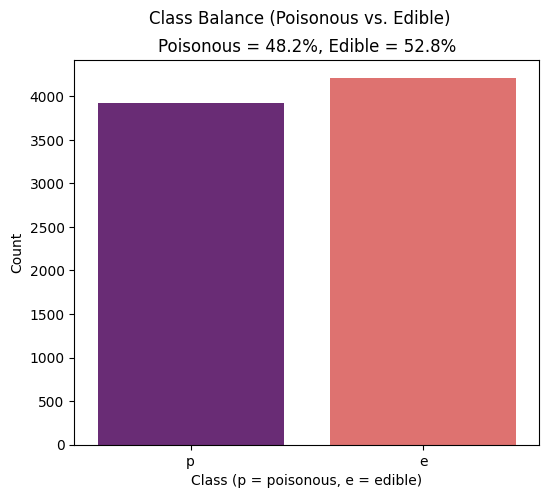

In [7]:
# visualize balance of class counts (edible and poisonous)
# tried using GenAI to teach me how to add bar labels for the percentages,
#but it got way complicated. Added the percentages to the title instead.
plt.figure(figsize=(6,5))
sns.countplot(x='class', hue='class', data=data, palette='magma', legend=False)
plt.suptitle("Class Balance (Poisonous vs. Edible)")
plt.title(f"Poisonous = 48.2%, Edible = 52.8%")
plt.xlabel("Class (p = poisonous, e = edible)")
plt.ylabel("Count")
plt.show()

In [8]:
# Feature unique values' balance
# Analyze distribution balance across features
feature_balance = {}

for feature in data.columns:
    # Exclude target variable
    if feature == 'class':
        continue

    # Get normalized value counts
    freq_dist = data[feature].value_counts(normalize=True)

    # Store summary statistics
    feature_balance[feature] = {
        'num_unique': len(freq_dist),
        'max_freq_percent': round(freq_dist.max() * 100, 2),
        'min_freq_percent': round(freq_dist.min() * 100, 2)
    }

# Used a bit of GenAI to help me figure out how to preprocess the data
# for the table and for plotting.

# Convert to DataFrame and sort by maximum frequency
balance_df = pd.DataFrame.from_dict(feature_balance, orient='index')
balance_df = balance_df.sort_values(by='max_freq_percent', ascending=False)
display(balance_df)

,num_unique,max_freq_percent,min_freq_percent
veil-color,4,97.54,0.10
gill-attachment,2,97.42,2.58
ring-number,3,92.17,0.44
gill-spacing,2,83.85,16.15
gill-size,2,69.08,30.92
stalk-surface-above-ring,4,63.71,0.30
stalk-surface-below-ring,4,60.76,3.50
bruises,2,58.44,41.56
stalk-shape,2,56.72,43.28
stalk-color-above-ring,9,54.95,0.10


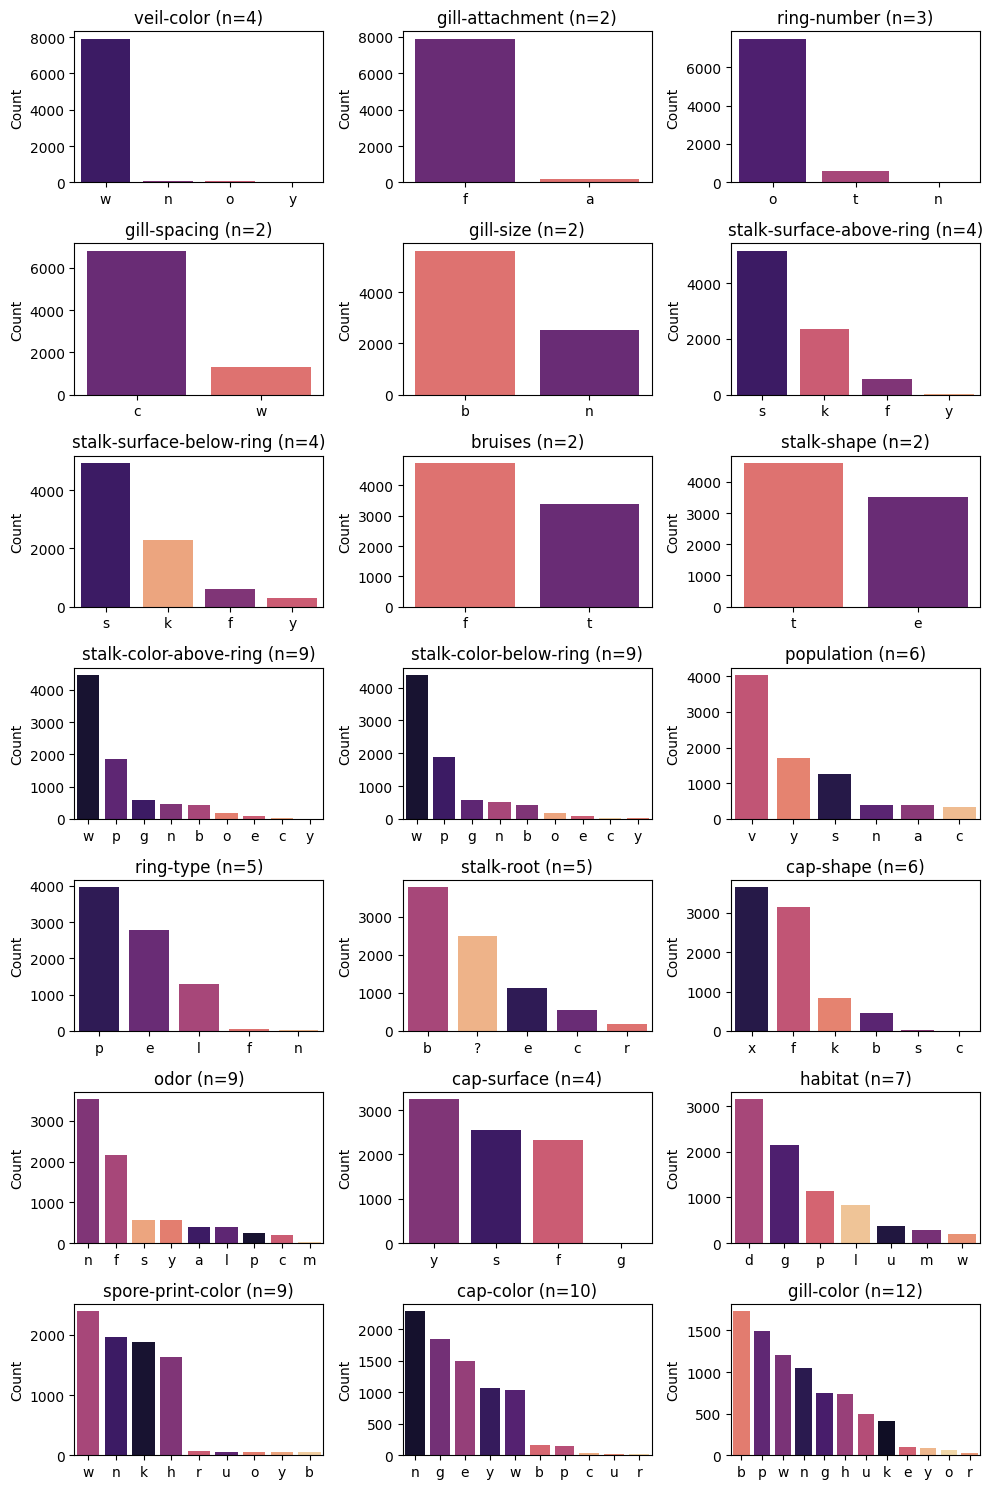

In [9]:
# Plot the features' distribution of unique values
most_imbalanced_features = balance_df.index.tolist()

fig, ax = plt.subplots(nrows=7, ncols=3, figsize=(10, 15))
ax = ax.ravel()

for idx, feature_name in enumerate(most_imbalanced_features):
    sorted_categories = data[feature_name].value_counts().index
    sns.countplot(data=data, x=feature_name, hue=feature_name,
                  order=sorted_categories, palette='magma',
                  ax=ax[idx], legend=False)
    ax[idx].set_title(f"{feature_name} (n={data[feature_name].nunique()})")
    ax[idx].set_ylabel("Count")
    ax[idx].set_xlabel("")

plt.tight_layout()
plt.show()

# Dataset Takeaways
Class balance looks great, nearly even split between poisonous and edible entry proportions.  
The features aren't as perfect, some are pretty badly skewed. The worst of them were veil-color (97.54% w), gill-attachment (97.42% f), and ring-number (92.17% o).   
gill-spacing was the next most skewed, but at 83.85% c, but this is much less imbalanced than the three mentioned above, which are 90+% dominated by one category.  
This imbalance of unique values within the features may hinder the model from correctly classifying the more rare categories correctly.

# Preprocessing - Encoding Classes
We will use One hot encoding to turn the categorical unique values into numbers for the model.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# separate predictor variables from target variable
X = data.drop(columns=['class'])
y = data['class']

# encode target variable: edible=0, poisonous=1
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:", label_encoder.classes_)
print("Encoded as:", label_encoder.transform(label_encoder.classes_))

Target classes: ['e' 'p']
Encoded as: [0 1]


In [11]:
# Encode features of split data.
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit and transform the data
X_encoded = encoder.fit_transform(X)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

Original shape: (8124, 21)
Encoded shape: (8124, 95)


# Train-Test Split
Split the data into 80% training data (6499 entries) and 20% testing data (1625 entries). This process also splits up x (feature class) and y (target class). The class distribution is even for both training and test data, as shown below.


In [16]:
# split data BEFORE encoding to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train/Test shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)

Train/Test shapes:
X_train: (6499, 95)  | y_train: (6499,)
X_test: (1625, 95)  | y_test: (1625,)


In [17]:
# Check class balance, all good!
print("Target class distribution:")
print("Train set:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)
print("\nTest set:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

Target class distribution:
Train set:
0    51.792583
1    48.207417
Name: proportion, dtype: float64

Test set:
0    51.815385
1    48.184615
Name: proportion, dtype: float64


# Build the NN model

- This model will output a binary clf, so we need a sigmoid output layer.  
- We went up to 2 hidden layers in class, so we'll try that.  
- Number of nodes for hidden layers: must be between input and output size, so we went with half and a quarter of the input size.
- Default Adam optimizer
- Loss function: Google identified "Binary Crossentropy" is best for karas and binary classificaiton in NN's.
- Tracking accuracy for model metrics

In [19]:
# imports
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# Define numbers of nodes for model based on x-train data row count
input_dim = X_train.shape[1]
hidden_1 = input_dim // 2  # 58 nodes
hidden_2 = hidden_1 // 2   # 29 nodes

# Build the model using 2 layers to keep it simple
model = Sequential([
    Dense(hidden_1, activation='relu', input_shape=(input_dim,)), # hidden layer 1
    Dense(hidden_2, activation='relu'),                           # hidden layer 2
    Dense(1, activation='sigmoid')  # binary classification output layer
])

# Compile with standard binary classification setup
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train with 20% validation split
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 47)             │         4,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 23)             │         1,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            24 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,640 (22.03 KB)

 Trainable params: 5,640 (22.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8555 - loss: 0.3657 - val_accuracy: 0.9954 - val_loss: 0.0327
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9968 - loss: 0.0195 - val_accuracy: 1.0000 - val_loss: 0.0070
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9993 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 7.0025e-04 - val_accuracy: 1.0000 - val_loss: 7.8459e-04
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 3.8774e-04 - val_accuracy: 1.0000 - val_loss: 5.8056e-04
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.8298e-0

# Model Training Results
Whabam, 100% accuracy by epoch 4! Let's hope that isn't due to overfitting. I used a bit of GenAI and talking to Christian to help me understand how the inputs and numbers of nodes work out to weights that inform such an outstanding model.  

Each layer connects fully to the next:  
 116 inputs × 58 neurons → 6,728 weights + 58 biases = 6,786 params.  
 58 × 29 → 1,682 weights + 29 biases = 1,711 params.  
 29 × 1 → 29 weights + 1 bias = 30 params.  
 Total of 8,527 trainable weights  

# Testing the Model

In [20]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.6f}")

Test Accuracy: 1.0000
Test Loss: 0.000220


# Wrap up
The neural network model performed to 100% accuracy and basically 0% loss (error) on both the training and testing data, which is pretty darned impressive. I learned a lot about neural networks by going through this assignment.


### Requirements:

**(a) Explore your data.** Review and understand your data. Look at it; use plots to help understand any key relationships. **There is no specific output required for this question**, but you are encouraged to explore the data personally before going further.

**(b) Preprocess your data.** Preprocess your data so it's ready for use for regression and describe what you did and why you did it. Preprocessing may include: normalizing data, handling missing or erroneous values, separating out a validation dataset, etc.
- Comment on each type of preprocessing that you apply and both how and why you apply it.

**(c) Select, train, and compare models.** Fit at least 5 models to the training data. Some of these can be experiments with different hyperparameter-tuned versions of the same model, although all 5 should not be the same type of model. There are no constraints on the types of models, but you're encouraged to explore examples we've discussed in class including:

1. Linear regression
2. Polynomial regression
3. Lasso regression
4. Ridge regression
5. Decision tree regression
6. Random forest regression
7. Support vector regression (we didn't explicitly cover this in class)


When selecting models, be aware that some models may take longer than others to train. Monitor your output and plan your time accordingly.

Assess the regression performance AND computational efficiency of the models you selected:

- Visualize the model fit to the training data. Using the models you created in part (c), plot the original data (as a scatter plot) AND the curves representing your models (each as a separate curve) from (c). One of these models should also be your BEST performing submission (based on evalutation using your test dataset). Label it as such.
- As you train and validate each model, time how long it takes to train and validate in each case and create a plot that shows both the training and prediction time for each model included.
- Describe:
  - Your process of model selection and hyperparameter tuning
  - Which model performed best and your process for identifying/selecting it

**(d) Apply your model "in practice".** Compare at least 5 different model results (using the test data provided). These do not need to be the same that you report on above, but you should select your *most competitive* models.
- Be sure to RETRAIN YOUR MODEL ON ALL LABELED TRAINING AND VALIDATION DATA before making your predictions on the test data for submission. This will help to maximize your performance on the test data.



### Guidance:
1. **Preprocessing**. You may need to preprocess the data for some of these models to perform well (scaling inputs or reducing dimensionality). Some of this preprocessing may differ from model to model to achieve the best performance. A helpful tool for creating such preprocessing and model fitting pipelines is the sklearn `pipeline` module which lets you group a series of processing steps together.
2. **Hyperparameters**. Hyperparameters may need to be tuned for some of the models you use. You may want to perform hyperparameter tuning for some of the models. `optuna` is a great framework for this, if you want to try it out. If you experiment with different hyperparameters that include many model runs, you may want to apply them to a small subsample of your overall data before running it on the larger training set to be time efficient (if you do, just make sure to ensure your selected subset is representative of the rest of your data).
3. **Validation data**. You're encouraged to create your own validation dataset for comparing model performance; without this, there's a significant likelihood of overfitting to the data. A common choice of the split is 80% training, 20% validation. Before you make your final predictions on the test data, be sure to retrain your model on the entire dataset.
